# Through focus scan of the grating writer head
khchan@lbl.gov, awojdyla@lbl.gov, meericksen@lbl.gov
July 2026

We want to perform a through focus scan of the grating writer head.
The laser is a Coherent Obis 405-100FP at 3mW, The stage is the Newport XML210-S, the camera is a Basler acA5472-5gm (monochrome, 2.4 pixel size). 

We are using a Mitutoyo lens 5x0.14NA with an MT-4 tube lend, a 20um x 10 mm slit and a ND4 neutral density filter.

## connecting to the instruments

### Basler camera

In [1]:
import time

from pypylon import pylon

def open_camera(device_index=0, exposure_us=0, gain=0.0):
    """
    Open a Basler camera with 12-bit Mono12p settings.

    Parameters:
        device_index : int
            Index of the camera to open.
        exposure_us : float
            Exposure time in microseconds.
        gain : float
            Camera gain.

    Returns:
        camera : pylon.InstantCamera
            Opened and configured camera object.
        converter : pylon.ImageFormatConverter
            Image converter for Mono16 output.
    """

    # Create the transport layer factory
    tl_factory = pylon.TlFactory.GetInstance()

    # Enumerate connected devices
    devices = tl_factory.EnumerateDevices() # Where those devices at?
    if len(devices) == 0:
        raise RuntimeError("No Basler cameras found!")

    # Error handling for invalid device index
    if device_index >= len(devices):
        raise ValueError(f"device_index {device_index} out of range ({len(devices)} devices found)")

    # Create camera object and open it
    camera = pylon.InstantCamera(tl_factory.CreateDevice(devices[device_index]))
    camera.Open()
    print("Connected to:", camera.GetDeviceInfo().GetModelName())

    # Configure pixel format and bit depth
    # camera.PixelFormat.Value = "Mono12p"  # 12-bit unpacked
    # camera.BslSensorBitDepthMode.Value = "Manual" # Set bit depth mode to manual
    # camera.BslSensorBitDepth.Value = "Bpp12" # Set bit depth to 12 bits per pixel
    # camera.ExposureTime.Value = exposure_us # Set exposure time
    # camera.Gain.Value = gain  # Set gain

    # Setup converter to Mono16 (12-bit packed → 16-bit container)
    converter = pylon.ImageFormatConverter()
    converter.OutputPixelFormat = pylon.PixelType_Mono16
    converter.OutputBitAlignment = pylon.OutputBitAlignment_MsbAligned

    return camera, converter

In [2]:
import numpy as np

def capture_image(camera, converter, extra_margin_ms=500):
    """
    Capture one image with timeout automatically matched to exposure time.

    Parameters:
    camera : pylon.InstantCamera
        Opened and configured camera object.
    converter : pylon.ImageFormatConverter
        Image converter.
    extra_margin_ms : int
        Extra margin in milliseconds to add to the timeout (default: 500 ms).

    Returns:
        img_12bit : np.ndarray
            Captured image as a 12-bit NumPy array.
    """

    #exposure_us = camera.ExposureTime.Value # Exposure is in microseconds
    exposure_us = camera.ExposureTimeAbs.GetValue() 

    exposure_ms = exposure_us / 1000.0 # Exposure in milliseconds

    # Timeout = exposure + margin (this exists to prevent an error, so be cautious about changing this code)
    timeout_ms = int(exposure_ms * 1.5 + extra_margin_ms)
    
    # Camera must be grabbing before we can retrieve results
    if not camera.IsGrabbing():
        camera.StartGrabbing(pylon.GrabStrategy_OneByOne)

    # Retrieve the image result
    grab = camera.RetrieveResult(timeout_ms, pylon.TimeoutHandling_ThrowException)

    # Throw an error if the grab failed
    if not grab.GrabSucceeded():
        grab.Release()
        raise RuntimeError("Camera failed to capture image")

    # Convert the image to a NumPy array and release the grab
    img = converter.Convert(grab).GetArray().astype(np.float32)
    grab.Release()

    return img

In [3]:
import ophyd
from ophyd import Device, Component as Cpt, Signal
from ophyd.status import Status, SubscriptionStatus

class BaslerCamera(Device):
    """
    Ophyd Device for a Basler camera using pypylon.
    This is the scaffolding for future development of Bluesky's ophyd support for Basler cameras.
    """

    image = Cpt(Signal, value=None, kind="hinted")

    def __init__(self, camera, converter, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.camera = camera
        self.converter = converter

    def trigger(self):

        status = Status()

        img = capture_image(self.camera, self.converter)

        self.image.put(img)

        status.set_finished()

        return status

    def read(self):

        img = self.image.get()

        return {
            f"{self.name}_image": {
                "value": img,
                "timestamp": time.time()
            }
        }

    def describe(self):

        img = self.image.get()

        shape = img.shape if img is not None else []

        return {
            f"{self.name}_image": {
                "dtype": "array",
                "shape": shape,
                "source": "BaslerCamera"
            }
        }

In [4]:
exposure_time_us = 1500. # Value for exposure time
gain = 0 # Value for gain
camera_hw, converter = open_camera(device_index=1, exposure_us=exposure_time_us, gain=gain) # Open the camera with specified settings

# Ophyd camera device
camera_dev = BaslerCamera(camera=camera_hw, converter=converter, name="camera")

# Stop grabbing first, because we need to change some settings
if camera_hw.IsGrabbing():
    camera_hw.StopGrabbing()

# Set full frame (ORDER MATTERS)
camera_hw.Width.Value = camera_hw.Width.GetMax()
camera_hw.Height.Value = camera_hw.Height.GetMax()
camera_hw.OffsetX.Value = 0
camera_hw.OffsetY.Value = 0

print(camera_dev.read())    # Honestly, consider me a skeptic of this line of code


Connected to: acA5472-5gm
{'camera_image': {'value': None, 'timestamp': 1784315020.5443687}}


Max pixel value: 45312.0
Camera exposure time (us):  1508.0


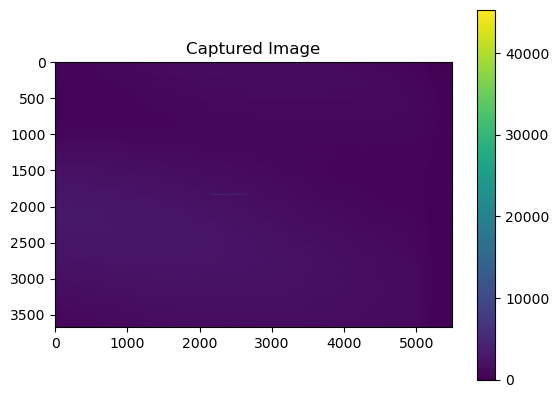

In [43]:
import matplotlib.pyplot as plt
img = capture_image(camera_hw, converter) # Capture an image with the current camera settings
plt.imshow(img, cmap='viridis')
plt.colorbar()
plt.title("Captured Image")
print("Max pixel value:", img.max())

#print("Camera exposure time (us): ", camera_hw.ExposureTime.Value)
print("Camera exposure time (us): ", camera_hw.ExposureTimeAbs.GetValue())
#print("Camera gain: ", camera_hw.Gain.Value)



In [44]:
camera_hw.Close() # We close the camera because it would have been more inconvenient not to

In [ ]:
    camera.ExposureAuto.SetValue('Off')
    camera.ExposureTimeAbs.SetValue(1500) 

### Newport

In [ ]:
from newportxps import NewportXPS

# This cell of code is for going to the center of a grating,
# which is an ideal position for focusing.

# If you put the IP address into your browser you can also connect to the stage's web interface.
# The password and username are both "Administrator" by default.
STAGE_NAME = 'Group1.Pos'
IP_ADDRESS = '192.168.10.20'
USERNAME = 'Administrator'
PASSWORD = 'Administrator'

# Connect to the controller
xps = NewportXPS(IP_ADDRESS, username=USERNAME, password=PASSWORD)

time.sleep(0.1)  # Small delay to ensure connection is established

xps._xps.PositionerSGammaParametersSet(
    xps._sid,
    STAGE_NAME,
    3.0, # Velocity
    1.0, # Acceleration
    0.01,
    0.01
)

#time.sleep(0.1)  # Small delay to ensure parameters are set before moving

#xps.set_velocity(STAGE_NAME, 5)  # Set a safe velocity for testing

#time.sleep(0.1)  # Small delay to ensure velocity is set before moving

# xps.move_stage(STAGE_NAME, 30.0)  # Move to a known center position for focusing on the grating (might need to be adjusted)

#time.sleep(0.1)  # Wait for move to complete and position to stabilize

In [31]:
xps.get_stage_position(STAGE_NAME)

25.0

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from ophyd import Device, Component as Cpt, Signal
from ophyd.status import Status

class NewportXPSMotor(Device):
    """
    Ophyd Device for a Newport XPS motor stage.
    This is the scaffolding for future development of Bluesky's ophyd support for Newport XPS stages.
    """
    user_setpoint = Cpt(Signal, value=0, kind='normal')

    _executor = ThreadPoolExecutor(max_workers=1)

    def __init__(self, ip_address, stage_name, username='Administrator', password='Administrator', *args, **kwargs):
        super().__init__(*args, **kwargs)
        from newportxps import NewportXPS
        self.stage_name = stage_name
        self.xps = NewportXPS(ip_address, username=username, password=password)

    def move_to(self, position, velocity=None):
        """Non-blocking move, no stage polling."""
        status = Status()
        self.user_setpoint.put(position)

        if velocity is not None:
            self.xps.set_velocity(self.stage_name, velocity)

        # start move in background
        self._executor.submit(self.xps.move_stage, self.stage_name, position)

        # immediately mark as finished (we don't poll stage)
        status.set_finished()
        return status

In [41]:
import time
import threading
from ophyd import Device, Component as Cpt, Signal, SignalRO, Kind
from ophyd.status import DeviceStatus
from newportxps import NewportXPS

class XPSPositionSignal(SignalRO):
    def get(self, **kwargs):
        """Query the hardware directly for the current position."""
        position = self.parent.xps.get_stage_position(self.parent.stage_name)
        self._readback = position
        return position

class NewportXPSStage(Device):
    # Configuration parameters: stored once per run in Tiled's descriptor
    velocity = Cpt(Signal, value=3.0, kind=Kind.config)
    acceleration = Cpt(Signal, value=1.0, kind=Kind.config)
    
    # Hinted: Tiled and standard Bluesky tools will use this as the primary field
    current_position = Cpt(XPSPositionSignal, kind=Kind.hinted)

    def __init__(self, prefix="", *, ip_address, username, password, stage_name, name="xps_stage", **kwargs):
        super().__init__(prefix, name=name, **kwargs)
        self.stage_name = stage_name
        self.xps = NewportXPS(ip_address, username=username, password=password)
        self._done = True  # Track the motion state locally
        
        time.sleep(0.1)
        
        # Apply parameters immediately upon connection
        self._apply_gamma_parameters()

    def _apply_gamma_parameters(self, min_jerk=0.01, max_jerk=0.01):
        """Sends the current velocity and acceleration signals to the controller."""
        self.xps._xps.PositionerSGammaParametersSet(
            self.xps._sid,
            self.stage_name,
            self.velocity.get(),
            self.acceleration.get(),
            min_jerk,
            max_jerk
        )

    def stage(self):
        """Bluesky calls this before a plan starts, ensuring settings are fresh."""
        self._apply_gamma_parameters()
        return super().stage()

    def set(self, target_position):
        """Called by Bluesky (e.g., bps.mv) to move the stage. Returns a status object."""
        status = DeviceStatus(self)
        self._done = False

        def move_thread():
            try:
                # Send the move command via the XPS API
                group_name = self.stage_name.split('.')[0]
                self.xps._xps.GroupMoveAbsolute(self.xps._sid, group_name, [target_position])
                
                # Poll the controller until the motion is complete
                done_status = 0
                while done_status == 0 and not self._done:
                    error_code, done_status = self.xps._xps.PositionerMotionDoneGet(
                        self.xps._sid, 
                        self.stage_name
                    )
                    time.sleep(0.1)  # Avoid flooding the socket with requests
                
                # Mark as finished
                self._done = True
                status.set_finished()
            except Exception as exc:
                self._done = True
                status.set_exception(exc)

        # Run the move in a separate thread so it doesn't block the Bluesky run engine
        threading.Thread(target=move_thread, daemon=True).start()
        return status

    def stop(self, *, success=False):
        """Called by Bluesky if a plan is aborted (e.g., via Ctrl+C)."""
        self._done = True
        try:
            group_name = self.stage_name.split('.')[0]
            self.xps._xps.GroupMoveAbort(self.xps._sid, group_name)
        except Exception as exc:
            print(f"Failed to abort motion on {self.name}: {exc}")
        super().stop(success=success)

    @property
    def position(self):
        """Standard positioner interface: hardware readback."""
        return self.current_position.get()

    @property
    def done(self):
        """Standard positioner interface: True if idle, False if moving."""
        return self._done


# Instantiate your new full-featured Ophyd object
grating_stage = NewportXPSStage(
    ip_address='192.168.10.20',
    username='Administrator',
    password='Administrator',
    stage_name='Group1.Pos',
    name='grating_stage'
)

In [42]:
grating_stage.set(30)

DeviceStatus(device=grating_stage, done=False, success=False)

In [4]:
from bluesky import RunEngine

RE = RunEngine({})

from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri
#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")
api_key = api_key.strip(' \'"“”')
# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.240:8000", api_key=api_key)
tw = TiledWriter(tiled_client)
RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

1